In [2]:
#Setup & Libraries
# Install required libraries
!pip install pandas lxml Pillow matplotlib openpyxl

import pandas as pd
import numpy as np
import json
import xml.etree.ElementTree as ET
import xml.etree.ElementTree as etree
import urllib.request
import matplotlib.pyplot as plt
from PIL import Image

print("--- Step 1: Libraries Installed and Imported Successfully ---")

--- Step 1: Libraries Installed and Imported Successfully ---


In [3]:
#CSV Files
print("\n--- Step 2: Working with CSV Files ---")
# URL for addresses.csv
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/labs/Module%205/data/addresses.csv'
df = pd.read_csv(url, header=None)

# Adding column names
df.columns = ['First Name', 'Last Name', 'Location', 'City', 'State', 'Area Code']
print("Initial DataFrame:")
print(df.head(2))

# Selecting columns
first_name_col = df["First Name"]
multiple_cols = df[['First Name', 'Last Name', 'Location', 'City', 'State', 'Area Code']]

# Selecting rows using .loc (Label-based)
print("\nRow selection using .loc[0]:")
print(df.loc[0])
print("\nRows 0,1,2 of 'First Name' using .loc:")
print(df.loc[[0, 1, 2], "First Name"])

# Selecting rows using .iloc (Index-based)
print("\nRows 0,1,2 of index 0 using .iloc:")
print(df.iloc[[0, 1, 2], 0])


--- Step 2: Working with CSV Files ---
Initial DataFrame:
  First Name Last Name           Location       City State  Area Code
0       John       Doe  120 jefferson st.  Riverside    NJ       8075
1       Jack  McGinnis       220 hobo Av.      Phila    PA       9119

Row selection using .loc[0]:
First Name                 John
Last Name                   Doe
Location      120 jefferson st.
City                  Riverside
State                        NJ
Area Code                  8075
Name: 0, dtype: object

Rows 0,1,2 of 'First Name' using .loc:
0             John
1             Jack
2    John "Da Man"
Name: First Name, dtype: object

Rows 0,1,2 of index 0 using .iloc:
0             John
1             Jack
2    John "Da Man"
Name: First Name, dtype: object


In [4]:
#Transform Function in Pandas
print("\n--- Step 3: Transform Function ---")
# Creating a dummy DataFrame
df_trans = pd.DataFrame(np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]]), columns=['a', 'b', 'c'])
print("Original transform df:")
print(df_trans)

# Applying lambda to add 10 to each element
df_plus_10 = df_trans.transform(func=lambda x: x + 10)
print("\nAfter adding 10:")
print(df_plus_10)

# Finding the square root of each element
result_sqrt = df_trans.transform(func=['sqrt'])
print("\nAfter square root:")
print(result_sqrt)


--- Step 3: Transform Function ---
Original transform df:
   a  b  c
0  1  2  3
1  4  5  6
2  7  8  9

After adding 10:
    a   b   c
0  11  12  13
1  14  15  16
2  17  18  19

After square root:
          a         b         c
       sqrt      sqrt      sqrt
0  1.000000  1.414214  1.732051
1  2.000000  2.236068  2.449490
2  2.645751  2.828427  3.000000


In [5]:
#JSON File
print("\n--- Step 4: JSON Serialization & Deserialization ---")
person = {
    'first_name': 'Mark',
    'last_name': 'abc',
    'age': 27,
    'address': {
        "streetAddress": "21 2nd Street",
        "city": "New York",
        "state": "NY",
        "postalCode": "10021-3100"
    }
}

# Serialization using dump()
with open('person.json', 'w') as f:
    json.dump(person, f)

# Serialization using dumps() with indentation
json_object = json.dumps(person, indent=4)
with open("sample.json", "w") as outfile:
    outfile.write(json_object)
print("JSON object serialized and written to file.")

# Deserialization using load()
with open('sample.json', 'r') as openfile:
    json_loaded = json.load(openfile)
print("Loaded JSON Content:", json_loaded)


--- Step 4: JSON Serialization & Deserialization ---
JSON object serialized and written to file.
Loaded JSON Content: {'first_name': 'Mark', 'last_name': 'abc', 'age': 27, 'address': {'streetAddress': '21 2nd Street', 'city': 'New York', 'state': 'NY', 'postalCode': '10021-3100'}}


In [7]:
#XLSX
print("\n--- Step 5: Working with Excel ---")
# Full original IBM URL for sample.xlsx
excel_url = "https://go.microsoft.com/fwlink/?LinkID=521962"
urllib.request.urlretrieve(excel_url, "sample.xlsx")

df_excel = pd.read_excel("sample.xlsx")
print("Excel Data Head:")
print(df_excel.head(2))


--- Step 5: Working with Excel ---
Excel Data Head:
      Segment  Country    Product Discount Band  Units Sold  \
0  Government   Canada  Carretera           NaN      1618.5   
1  Government  Germany  Carretera           NaN      1321.0   

   Manufacturing Price  Sale Price  Gross Sales  Discounts    Sales     COGS  \
0                    3          20      32370.0        0.0  32370.0  16185.0   
1                    3          20      26420.0        0.0  26420.0  13210.0   

    Profit       Date  Month Number Month Name  Year  
0  16185.0 2014-01-01             1    January  2014  
1  13210.0 2014-01-01             1    January  2014  


In [8]:
#XML
print("\n--- Step 6: Working with XML ---")
# Part A: Writing XML with xml.etree.ElementTree
employee = ET.Element('employee')
details = ET.SubElement(employee, 'details')
first = ET.SubElement(details, 'firstname')
second = ET.SubElement(details, 'lastname')
third = ET.SubElement(details, 'age')

first.text = 'Shiv'
second.text = 'Mishra'
third.text = '23'

mydata1 = ET.ElementTree(employee)
with open("new_sample.xml", "wb") as files:
    mydata1.write(files)
print("Custom XML document created successfully.")

# Part B: Reading XML via etree parsing loop
!curl -s -o Sample-employee-XML-file.xml https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/labs/Module%205/data/Sample-employee-XML-file.xml

tree = etree.parse("Sample-employee-XML-file.xml")
root = tree.getroot()

columns = ["firstname", "lastname", "title", "division", "building", "room"]
dataframe_xml = pd.DataFrame(columns=columns)

for node in root:
    firstname = node.find("firstname").text if node.find("firstname") is not None else ""
    lastname = node.find("lastname").text if node.find("lastname") is not None else ""
    title = node.find("title").text if node.find("title") is not None else ""
    division = node.find("division").text if node.find("division") is not None else ""
    building = node.find("building").text if node.find("building") is not None else ""
    room = node.find("room").text if node.find("room") is not None else ""

    employee_data = pd.Series([firstname, lastname, title, division, building, room], index=columns)
    dataframe_xml = pd.concat([dataframe_xml, employee_data.to_frame().T], ignore_index=True)

print("Parsed XML via ElementTree Loop:")
print(dataframe_xml.head(2))

# Part C: Reading XML file using pandas.read_xml function directly
df_read_xml = pd.read_xml("Sample-employee-XML-file.xml", xpath="/employees/details")
print("\nParsed XML via pd.read_xml function:")
print(df_read_xml.head(2))

# Part D: Saving Data back to a clean CSV format
df_read_xml.to_csv("employee.csv", index=False)
print("\nDataFrame exported to 'employee.csv'.")


--- Step 6: Working with XML ---
Custom XML document created successfully.
Parsed XML via ElementTree Loop:
  firstname lastname      title  division building room
0      Shiv   Mishra   Engineer  Computer      301   11
1       Yuh    Datta  developer  Computer      303   02

Parsed XML via pd.read_xml function:
  firstname lastname      title  division  building  room
0      Shiv   Mishra   Engineer  Computer       301    11
1       Yuh    Datta  developer  Computer       303     2

DataFrame exported to 'employee.csv'.



--- Step 7: Reading and Displaying Binary/Image File ---
Image Dimensions: (1999, 1499)


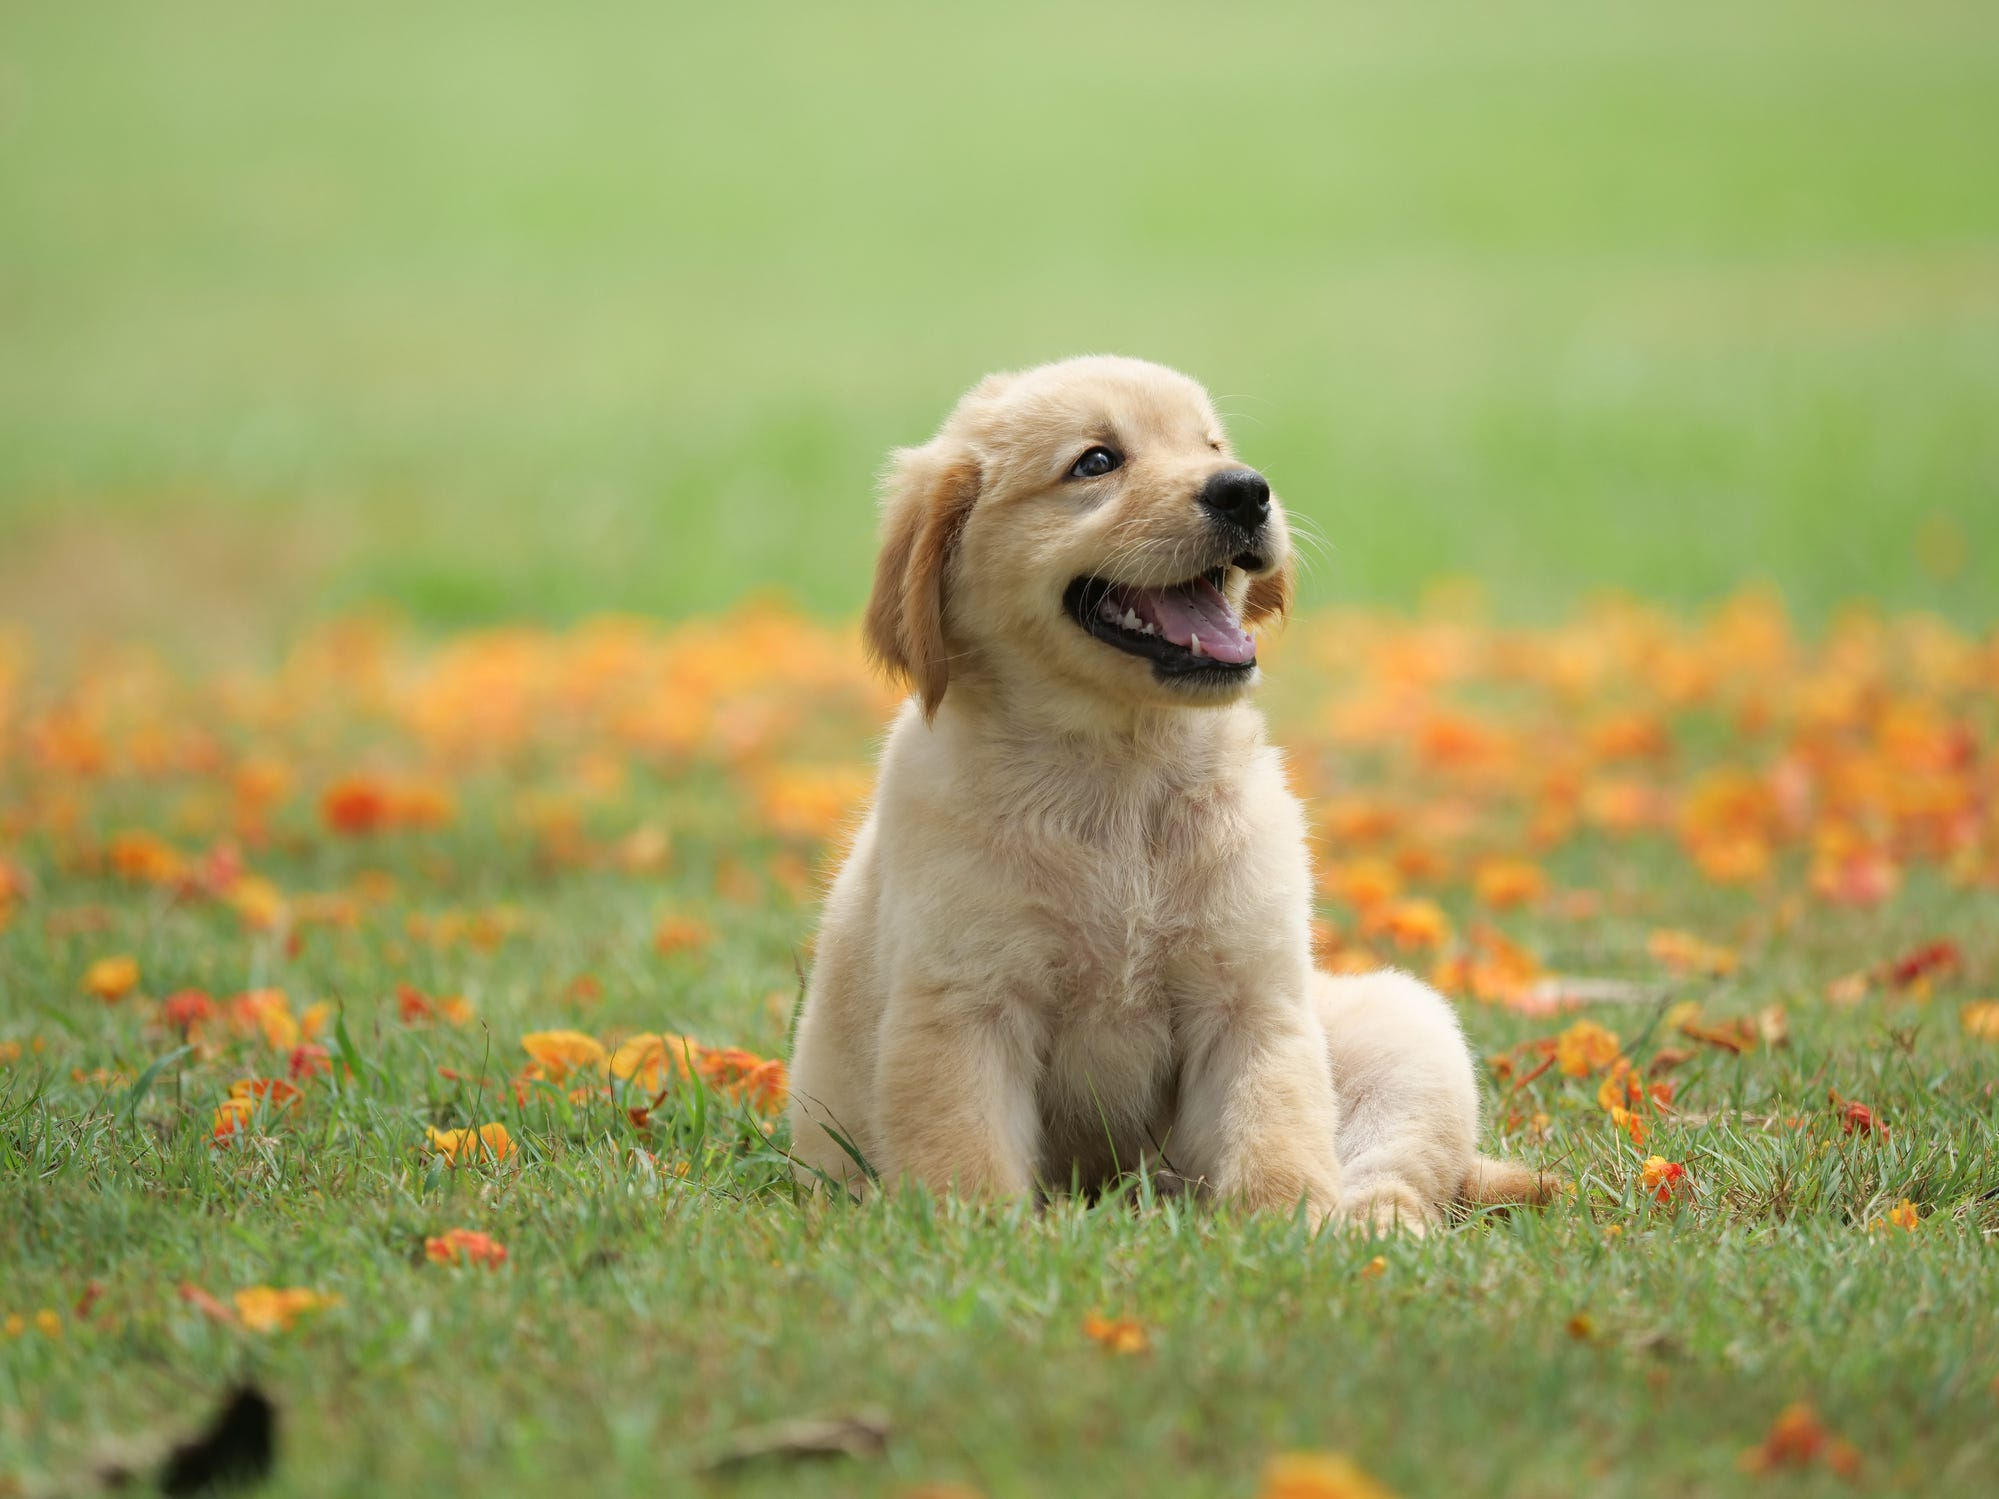

In [9]:
#Binary File Format / Images
print("\n--- Step 7: Reading and Displaying Binary/Image File ---")
# Restored complete path to the puppy asset
img_url = "https://hips.hearstapps.com/hmg-prod.s3.amazonaws.com/images/dog-puppy-on-garden-royalty-free-image-1586966191.jpg"
urllib.request.urlretrieve(img_url, 'dog.jpg')

img = Image.open('dog.jpg')
print("Image Dimensions:", img.size)
display(img)


--- Step 8: Data Analysis on Diabetes Dataset ---
The first 5 rows of the dataframe:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

The last 5 rows of the dataframe:
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
763           10      101             76             48      180  32.9   
764            2      122         

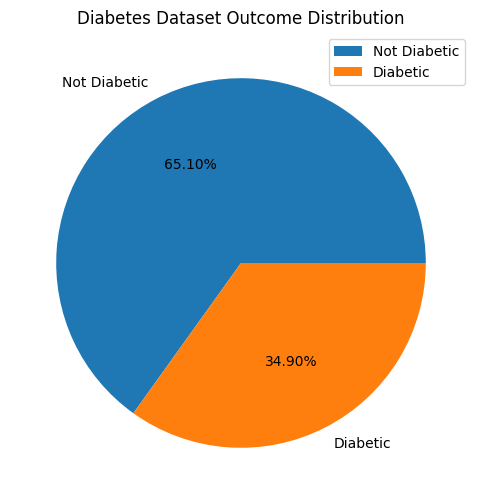

In [10]:
#Data Analysis & Visualization (Diabetes Dataset)
print("\n--- Step 8: Data Analysis on Diabetes Dataset ---")
# Restored full URL for diabetes.csv data asset
path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/labs/Module%205/data/diabetes.csv"
df_diabetes = pd.read_csv(path)

print("The first 5 rows of the dataframe:")
print(df_diabetes.head(5))
print("\nThe last 5 rows of the dataframe:")
print(df_diabetes.tail(5))

print("\nDataframe Dimensions (Shape):", df_diabetes.shape)
print("\nDataframe Structural Info:")
df_diabetes.info()
print("\nStatistical Overview of Dataset:")
print(df_diabetes.describe())

# Identify missing values
missing_data = df_diabetes.isnull()
print("\nChecking for missing values across columns:")
for column in missing_data.columns.values.tolist():
    print(f"Column: {column}")
    print(missing_data[column].value_counts())
    print("")

print("Data Types Checklist:")
print(df_diabetes.dtypes)

# Visualization Target Analysis
labels = ['Not Diabetic', 'Diabetic']
plt.figure(figsize=(6, 6))
plt.pie(df_diabetes['Outcome'].value_counts(), labels=labels, autopct='%0.02f%%')
plt.legend()
plt.title("Diabetes Dataset Outcome Distribution")
plt.show()